# Тестирование модели YOLOv8 версии nano, дообученной на задачу детекции автомобилей на дорожных фотографиях.

## Загружаем обученную модель

In [1]:
from ultralytics import YOLO
model = YOLO('C:\\users\\sasha\\Desktop/Car detect/New_hope/runs/detect/train23/weights/best.pt')

## Подадим на вход нейросети тестовые данные из обучающего датасета

In [3]:
model_results = model.val(data='C:\\users\\sasha\\Desktop/Car detect/New_hope/dataset/data.yaml', split='test')

Ultralytics 8.3.110  Python-3.12.9 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1660, 6144MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 50.616.0 MB/s, size: 36.7 KB)


val: Scanning C:\Users\sasha\Desktop\Car detect\New_hope\dataset\test\labels.cache... 1489 images, 202 backgrounds, 0 corrupt: 100%|██████████| 1489/1489 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 94/94 [00:14<00:00,  6.29it/s]


                   all       1489       9602      0.843      0.504      0.585      0.326
                 biker        124        181      0.784      0.591      0.648      0.338
                   car       1260       6441      0.847      0.761      0.828      0.537
            pedestrian        340        938      0.695      0.456      0.545      0.246
          trafficLight        167        267      0.819      0.663      0.759      0.403
    trafficLight-Green        197        547      0.749      0.534      0.581      0.241
trafficLight-GreenLeft         25         43      0.866      0.326      0.453      0.261
      trafficLight-Red        253        665      0.872      0.672      0.752      0.415
  trafficLight-RedLeft        105        145      0.854      0.676      0.761      0.432
   trafficLight-Yellow         14         40          1      0.141      0.337      0.165
trafficLight-YellowLeft          4          4          1          0          0          0
                 tru

## Выведем нормализованную Confusion Matrix

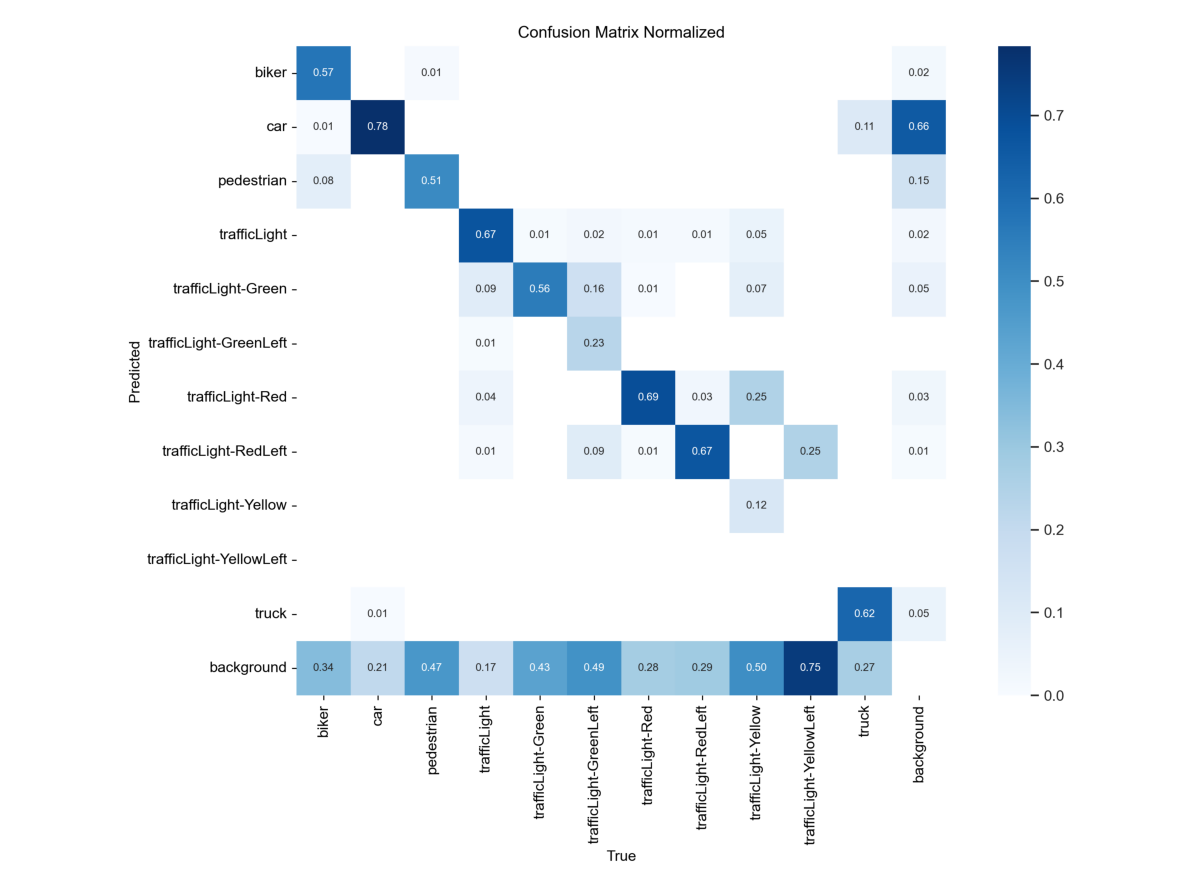

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("runs/detect/val2/confusion_matrix_normalized.png")
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Выводы по матрице
1) Большая часть машин была обнаружена и правильно классфицирована. Аналогично с классами "biker", "pedestrant", "truck"
2) Ошибка классификации минимально, основные недочёты связаны с детекцией объектов. Это связанно с тем, что в тестовых данных на фотографиях много мелких объектов, которые достаточно сложно детектировать с таким количеством параметров модели 

## Рассмотрим графики точности (precision) и полноты (recall) от порога уверенности (confidence)

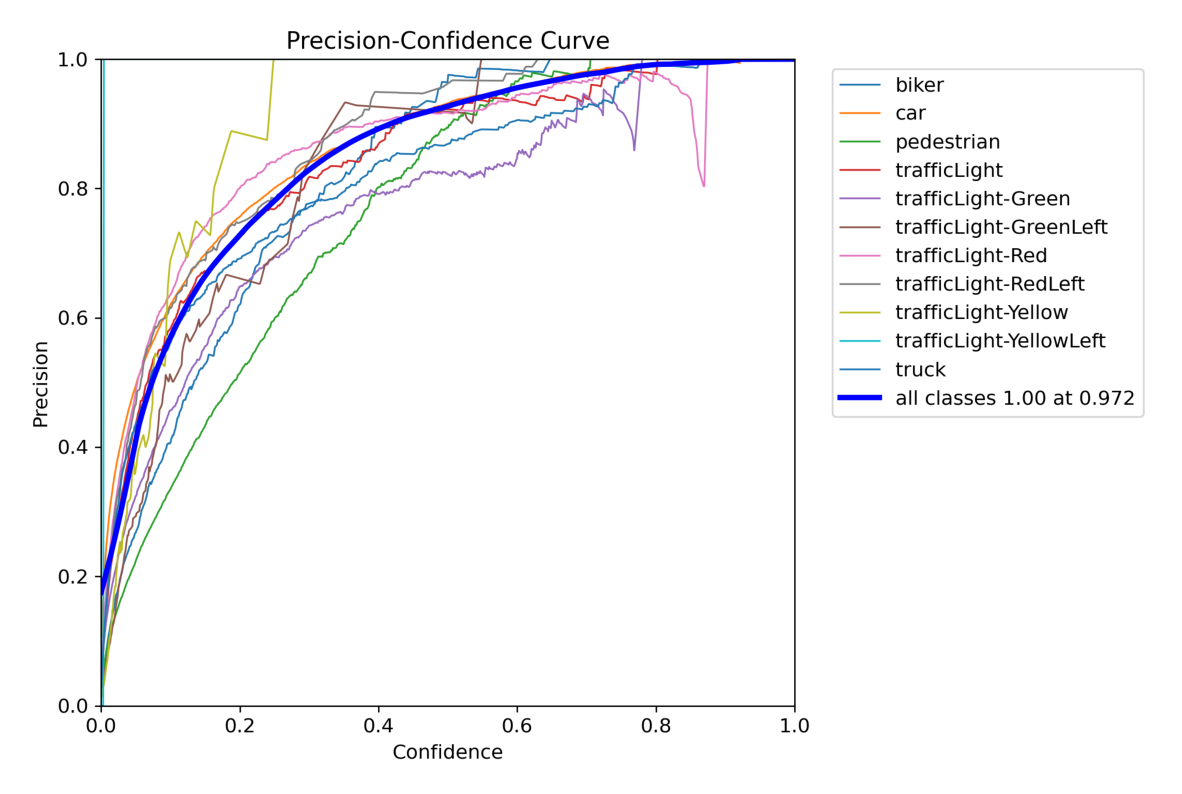

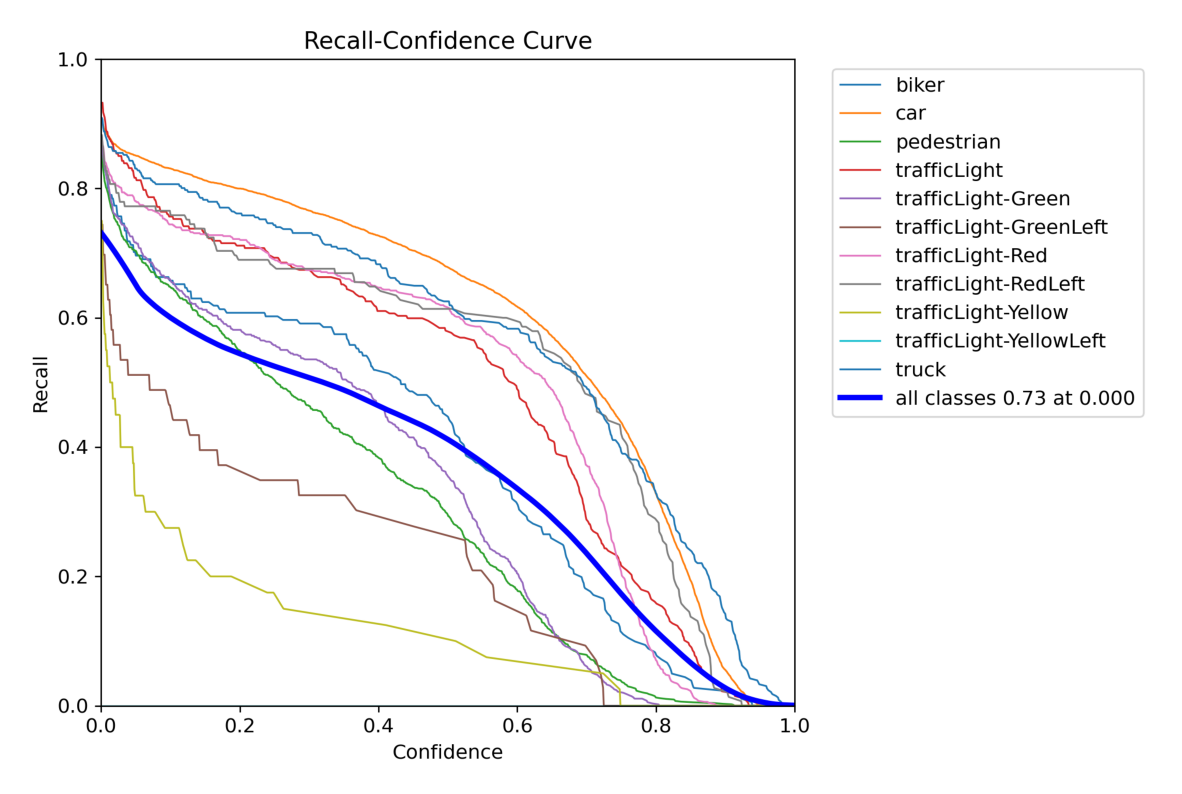

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("runs/detect/val2/P_curve.png")
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
img = cv2.imread("runs/detect/val2/R_curve.png")
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Выводы по графику
Так как для задачи в равной мере важны как точность, так и полнота, то можно оставить значение по умолчанию для порога уверенности (0.25)

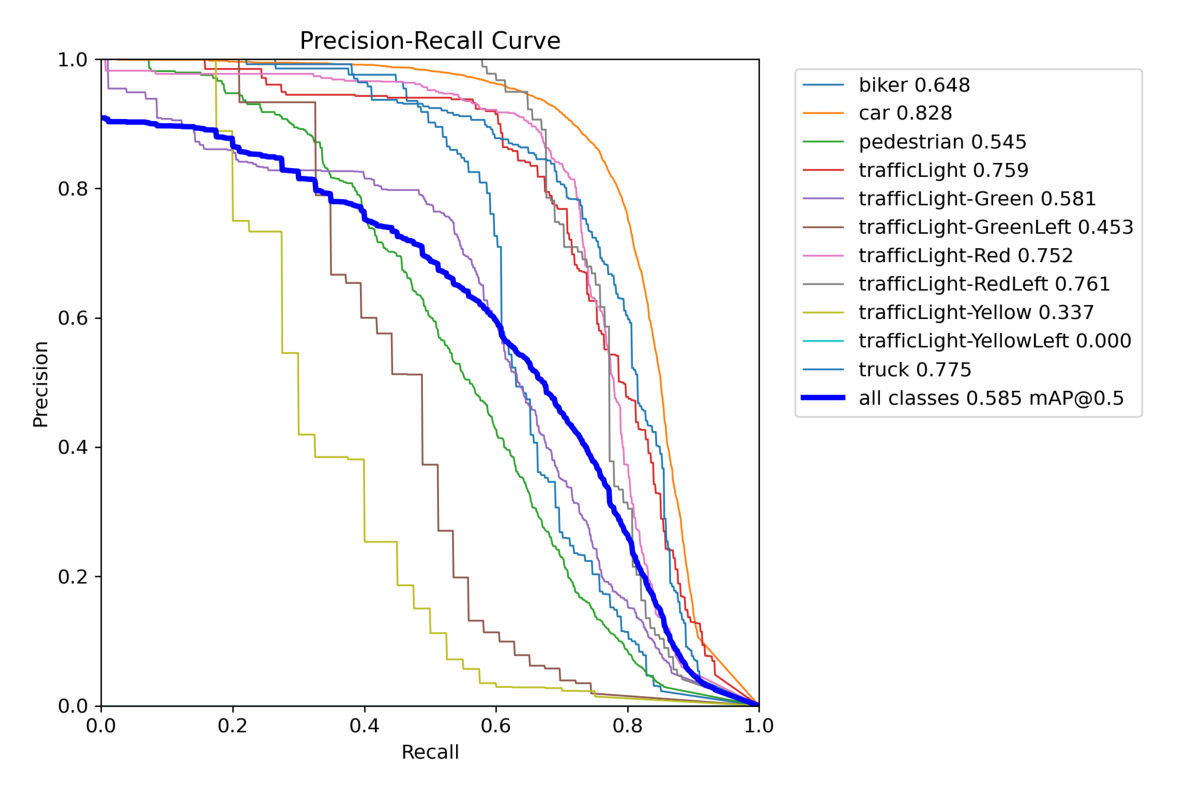

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("runs/detect/val2/PR_curve.png")
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Выводы по графику
Для ключевых классов (машины, мотоциклы, грузовики) площадь под кривыми недалека от единицы

## Проведём тест модели на данных не из обучающего датасета

In [9]:
results = model.predict('C:\\Users\\sasha\\Desktop\\Car detect\\For review\\img_for_test\\')
for result in results:
    result.save()  # Сохранить результат


image 1/4 C:\Users\sasha\Desktop\Car detect\For review\img_for_test\1003.jpg: 320x512 7 cars, 2 trafficLight-Reds, 1 trafficLight-RedLeft, 39.3ms
image 2/4 C:\Users\sasha\Desktop\Car detect\For review\img_for_test\10205.jpg: 320x512 5 cars, 35.9ms
image 3/4 C:\Users\sasha\Desktop\Car detect\For review\img_for_test\10400.jpg: 320x512 1 car, 1 truck, 27.1ms
image 4/4 C:\Users\sasha\Desktop\Car detect\For review\img_for_test\10420.jpg: 320x512 7 cars, 6 pedestrians, 2 trafficLight-Greens, 33.8ms
Speed: 4.0ms preprocess, 34.0ms inference, 49.3ms postprocess per image at shape (1, 3, 320, 512)


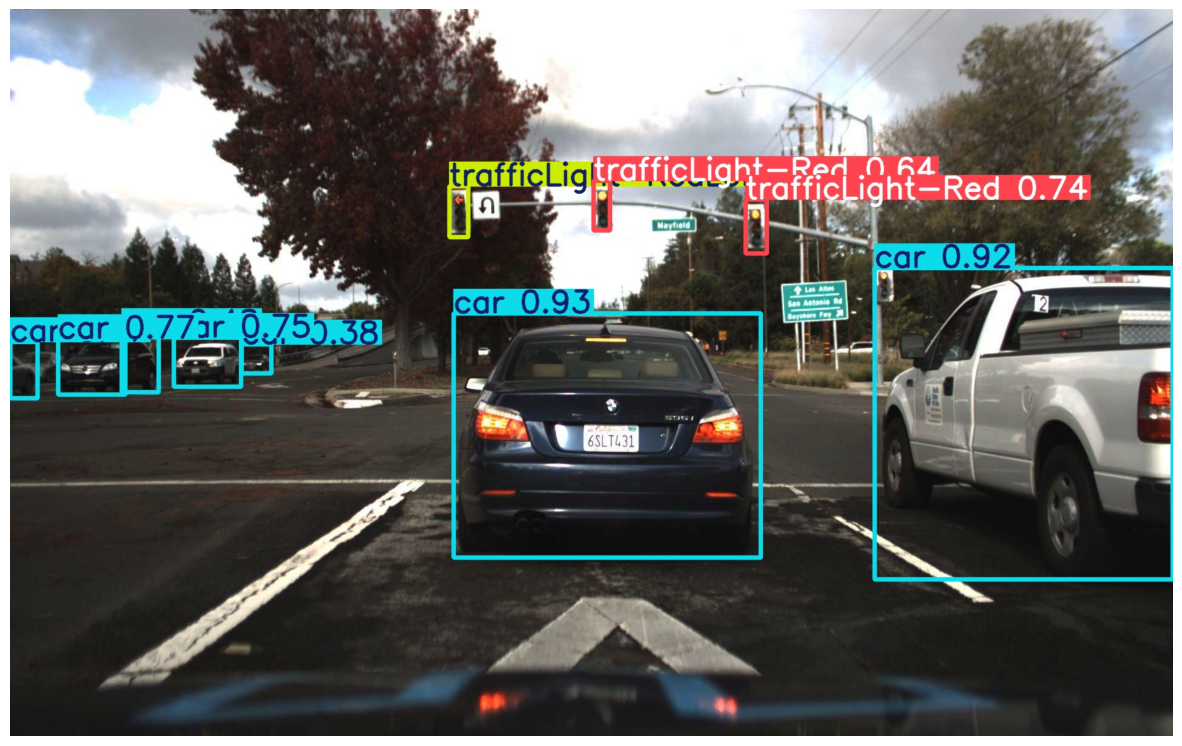

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("results_1003.jpg")
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

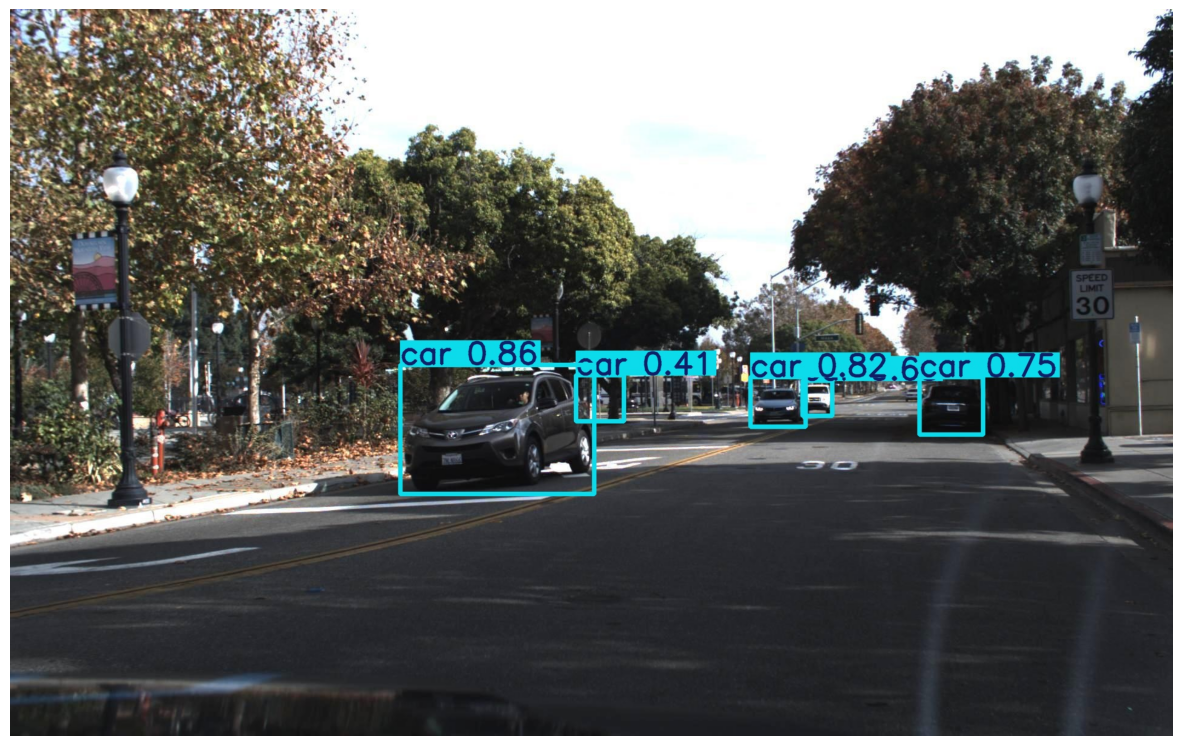

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("results_10205.jpg")
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

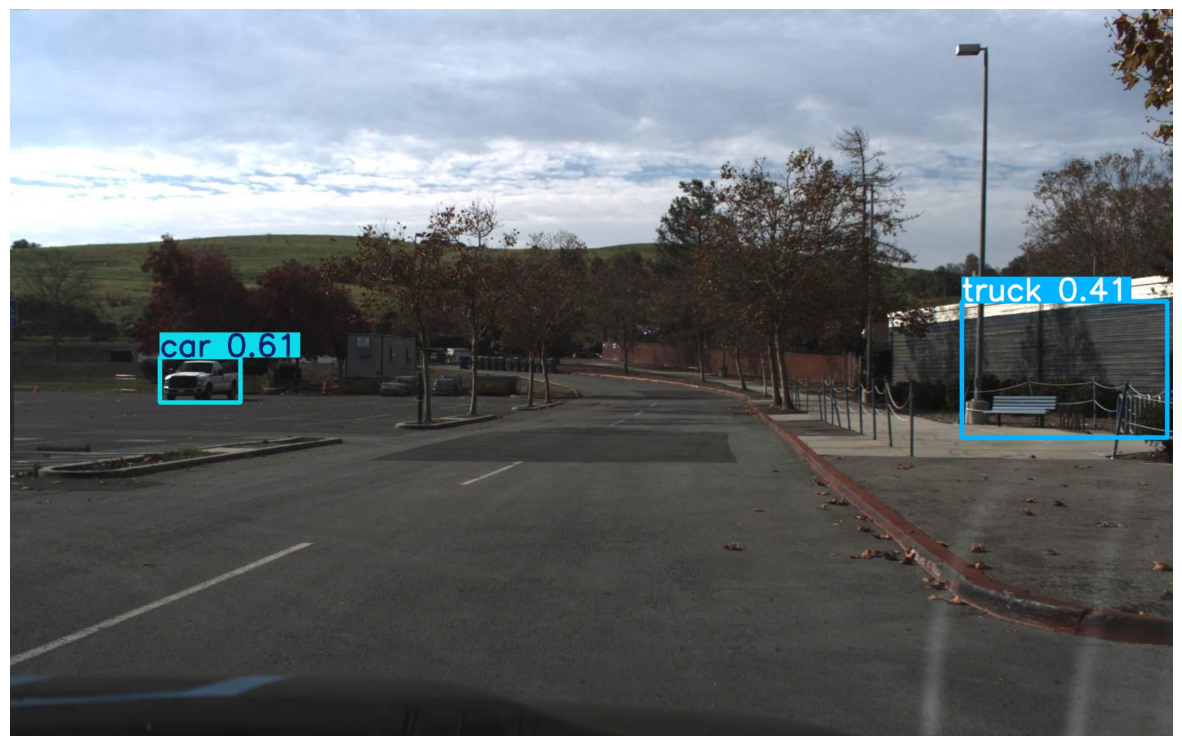

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("results_10400.jpg")
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Выводы по тестам
1) Модель отлично справляет с детекцией и классификацией автомобилей
2) Модель также обучилась различать различные знаки светофора
3) Класс грузовиков остаётся проблемным для модели

## Выведем стандартные метрики нашей модели и дадим им интерпритацию

### Average precision и mAP50

In [62]:
print('Average precision')
print()
for i in range(11):
    print(f'{model_results.names[i]} - {model_results.box.ap[i]}')
print()
print(f'mAP50 - {model_results.box.map50}')

Average precision

biker - 0.3382286337555519
car - 0.5366149474743249
pedestrian - 0.2462132331040014
trafficLight - 0.4034014616326919
trafficLight-Green - 0.24130185271886417
trafficLight-GreenLeft - 0.26050939365395726
trafficLight-Red - 0.4147911901720486
trafficLight-RedLeft - 0.43154534409495565
trafficLight-Yellow - 0.1649337483933948
trafficLight-YellowLeft - 0.0
truck - 0.5458476453096368

mAP50 - 0.5853671507104488


### Интерпритация AP и mAP50
1) Для классов "car", "biker", "pedestrian", "truck" модель показывает неплохую точность (precision) при разных значениях IoU (от 0.5 до 0.95 с шагом 0.05)
2) Значение mAP50 (средняя AP по всем классам с IoU от 50 и более) указывает на то, что модель успешно справляется с задачей детекции и классификации заданных классов

### Precision, recall и f1-score

In [63]:
print('Precision')
print()
for i in range(11):
    print(f'{model_results.names[i]} - {model_results.box.p[i]}')

Precision

biker - 0.7840039188412813
car - 0.84653545111517
pedestrian - 0.694757714387303
trafficLight - 0.8194318896798843
trafficLight-Green - 0.7487862067946442
trafficLight-GreenLeft - 0.8664048477047213
trafficLight-Red - 0.8724250612672979
trafficLight-RedLeft - 0.8543928857652273
trafficLight-Yellow - 1.0
trafficLight-YellowLeft - 1.0
truck - 0.7821852403624672


### Интерпритация precision

Модель успешно детектирует и классифицирует ключевые классы для задачи при стандартных значениях порога уверенности (confidence) и IoU

In [64]:
print('Recall')
print()
for i in range(11):
    print(f'{model_results.names[i]} - {model_results.box.r[i]}')

Recall

biker - 0.5911602209944752
car - 0.7610619469026548
pedestrian - 0.4561879764465244
trafficLight - 0.6629213483146067
trafficLight-Green - 0.5338208409506399
trafficLight-GreenLeft - 0.32558139534883723
trafficLight-Red - 0.6721804511278195
trafficLight-RedLeft - 0.6758620689655173
trafficLight-Yellow - 0.14139173721376314
trafficLight-YellowLeft - 0.0
truck - 0.7268930688421992


### Интерпритация recall

Модель успешно покрывает все объекты интереса для задачи при стандартных значениях порога уверенности (confidence) и IoU

В нашей задаче в равной степени важны как точность (precision), так и полнота (recall), поэтому обратим внимание на f1-score для различных классах при стандартных значениях порога уверенности (confidence) и IoU

In [66]:
print('F1-score')
print()
for i in range(11):
    print(f'{model_results.names[i]} - {model_results.box.f1[i]}')

F1-score

biker - 0.6740605233904681
car - 0.8015264510159215
pedestrian - 0.5507473000178522
trafficLight - 0.7329142329037686
trafficLight-Green - 0.6232893906298533
trafficLight-GreenLeft - 0.47330294438645676
trafficLight-Red - 0.7593227740700397
trafficLight-RedLeft - 0.7547131171802814
trafficLight-Yellow - 0.24775321671578365
trafficLight-YellowLeft - 0.0
truck - 0.7535262104056075


### Интерпритация f1-score

При решении задачи был соблюден баланс между точность (precision) и полнотой (recall), то есть покрыто достаточная часть всех объектов интереса с правильной классификацией